In [1]:
import pandas as pd
import numpy as np

nav = pd.read_csv("/workspaces/bluestock_mf_capstone/data/processed/clean_nav.csv")
perf = pd.read_csv("/workspaces/bluestock_mf_capstone/data/processed/clean_performance.csv")

nav["date"] = pd.to_datetime(nav["date"])

In [2]:
nav = nav.sort_values(["amfi_code", "date"])

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
    .pct_change()
)

nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [3]:
nav.to_csv(
    "/workspaces/bluestock_mf_capstone/data/processed/nav_returns.csv",
    index=False
)

In [4]:
cagr_data = []

for code, df in nav.groupby("amfi_code"):
    start_nav = df.iloc[0]["nav"]
    end_nav = df.iloc[-1]["nav"]

    years = (
        (df.iloc[-1]["date"] -
         df.iloc[0]["date"]).days
        / 365.25
    )

    if years > 0:
        cagr = ((end_nav/start_nav)
               **(1/years)-1)*100

        cagr_data.append(
            [code, cagr]
        )

cagr_df = pd.DataFrame(
    cagr_data,
    columns=["amfi_code","cagr_pct"]
)

cagr_df.head()

,amfi_code,cagr_pct
0,100016,2.637074
1,100025,4.458210
2,100033,30.123153
3,101206,23.538361
4,101207,7.938765


In [5]:
rf = 0.065

sharpe_data = []

for code, df in nav.groupby("amfi_code"):

    returns = df["daily_return"].dropna()

    if len(returns) > 0:

        sharpe = (
            (returns.mean()-rf/252)
            /
            returns.std()
        ) * np.sqrt(252)

        sharpe_data.append(
            [code, sharpe]
        )

sharpe_df = pd.DataFrame(
    sharpe_data,
    columns=["amfi_code","sharpe_ratio"]
)

In [6]:
mdd_data = []

for code, df in nav.groupby("amfi_code"):

    running_max = df["nav"].cummax()

    drawdown = (
        df["nav"] -
        running_max
    ) / running_max

    mdd = drawdown.min()

    mdd_data.append(
        [code, mdd]
    )

mdd_df = pd.DataFrame(
    mdd_data,
    columns=["amfi_code","max_drawdown"]
)

In [7]:
scorecard = (
    cagr_df
    .merge(sharpe_df,
           on="amfi_code")
    .merge(mdd_df,
           on="amfi_code")
)

scorecard.head()

,amfi_code,cagr_pct,sharpe_ratio,max_drawdown
0,100016,2.637074,-0.201517,-0.247344
1,100025,4.458210,-0.567095,-0.043083
2,100033,30.123153,1.093699,-0.162172
3,101206,23.538361,1.027213,-0.112916
4,101207,7.938765,0.162661,-0.354469


In [8]:
scorecard.to_csv(
    "/workspaces/bluestock_mf_capstone/data/processed/fund_scorecard.csv",
    index=False
)

In [9]:
sortino_data = []

for code, df in nav.groupby("amfi_code"):

    returns = df["daily_return"].dropna()

    downside = returns[returns < 0]

    if len(downside) > 0:

        sortino = (
            (returns.mean() - 0.065/252)
            /
            downside.std()
        ) * np.sqrt(252)

        sortino_data.append(
            [code, sortino]
        )

sortino_df = pd.DataFrame(
    sortino_data,
    columns=["amfi_code", "sortino_ratio"]
)

sortino_df.head()

,amfi_code,sortino_ratio
0,100016,-0.351047
1,100025,-0.941821
2,100033,1.829134
3,101206,1.799563
4,101207,0.276644


In [11]:
from sklearn.linear_model import LinearRegression

alpha_beta = []

for code, df in nav.groupby("amfi_code"):

    returns = df["daily_return"].dropna()

    if len(returns) > 30:

        X = np.arange(len(returns)).reshape(-1,1)
        y = returns.values

        model = LinearRegression()
        model.fit(X,y)

        alpha = model.intercept_
        beta = model.coef_[0]

        alpha_beta.append(
            [code, alpha, beta]
        )

alpha_beta_df = pd.DataFrame(
    alpha_beta,
    columns=[
        "amfi_code",
        "alpha",
        "beta"
    ]
)

alpha_beta_df.head()

,amfi_code,alpha,beta
0,100016,0.000249,-1.872632e-07
1,100025,0.000185,-2.623297e-08
2,100033,0.000698,6.649260e-07
3,101206,0.000111,1.290788e-06
4,101207,0.001688,-2.201496e-06


In [12]:
alpha_beta_df.to_csv(
    "/workspaces/bluestock_mf_capstone/data/processed/alpha_beta.csv",
    index=False
)

In [13]:
final_scorecard = (
    scorecard
    .merge(sortino_df,
           on="amfi_code")
    .merge(alpha_beta_df,
           on="amfi_code")
)

final_scorecard.head()

,amfi_code,cagr_pct,sharpe_ratio,max_drawdown,sortino_ratio,alpha,beta
0,100016,2.637074,-0.201517,-0.247344,-0.351047,0.000249,-1.872632e-07
1,100025,4.458210,-0.567095,-0.043083,-0.941821,0.000185,-2.623297e-08
2,100033,30.123153,1.093699,-0.162172,1.829134,0.000698,6.649260e-07
3,101206,23.538361,1.027213,-0.112916,1.799563,0.000111,1.290788e-06
4,101207,7.938765,0.162661,-0.354469,0.276644,0.001688,-2.201496e-06


In [14]:
final_scorecard.to_csv(
    "/workspaces/bluestock_mf_capstone/data/processed/final_scorecard.csv",
    index=False
)

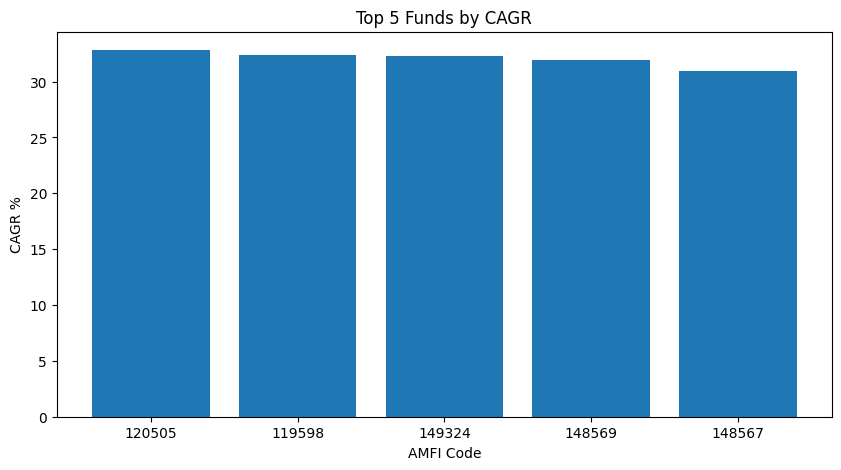

In [15]:
import matplotlib.pyplot as plt

top5 = final_scorecard.sort_values(
    "cagr_pct",
    ascending=False
).head(5)

plt.figure(figsize=(10,5))
plt.bar(top5["amfi_code"].astype(str),
        top5["cagr_pct"])

plt.title("Top 5 Funds by CAGR")
plt.xlabel("AMFI Code")
plt.ylabel("CAGR %")

plt.savefig(
    "/workspaces/bluestock_mf_capstone/reports/benchmark_comparison.png"
)

plt.show()